# Arctic Sea Ice Light Transmission For Ecosystem Dynamics: Analysis with cloud-based ICESat-2 and ERA5 (Earthmover) data

**Goal**: Combine ICESat-2 sea ice thickness and snow depth with ERA5 cloud cover to estimate
under-ice light availability using a simple Beer-Lambert transmission model.

This notebook:
1. Reads ICESat-2 monthly gridded sea ice thickness and ancillary state data, from S3 (Zarr) — **summer** (IS2SIT_SUMMER, 2019–2021) by default
2. Reads ERA5 total cloud cover from the [Earthmover catalog](https://app.earthmover.io/marketplace/695bff20622fd82a1ec88780)
3. Applies a two-layer (snow + ice) exponential light-decay model
4. **Compares** under-ice PAR across the three available summers for a chosen month (default: June)
5. Maps high-transmission regions and summarises year-to-year differences

Change `ANALYSIS_MONTH` in Section 1 to switch between May (5), June (6), or July (7).
Set `SEASON = "winter"` in Section 1 to load the winter dataset instead.

## Setup and imports

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from utils import (
    read_is2sitmogr4_v4,
    read_is2sit_summer,
    read_era5_earthmover,
    regrid_era5_to_is2,
    daily_mean_toa_insolation,
    add_arctic_features,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 10

## 1. Read ICESat-2 sea ice thickness

Two datasets are available on the same 25 km EASE2 grid:
- **Winter** (IS2SITMOGR4 V4): Nov 2018 – Apr 2025
- **Summer** (IS2SIT_SUMMER): May 2019 – Aug 2021

Set `SEASON` below to choose which one to load.

In [2]:
SEASON = "summer"  # "winter" or "summer"

if SEASON == "winter":
    is2_ds = read_is2sitmogr4_v4()
else:
    is2_ds = read_is2sit_summer()

print(is2_ds.head())

<xarray.Dataset> Size: 16kB
Dimensions:                         (time: 5, y: 5, x: 5)
Coordinates:
  * time                            (time) datetime64[ns] 40B 2019-05-01 ... ...
  * y                               (y) float32 20B 5.838e+06 ... 5.738e+06
  * x                               (x) float32 20B -3.838e+06 ... -3.738e+06
    latitude                        (y, x) float32 100B 31.1 31.2 ... 32.08
    longitude                       (y, x) float32 100B 168.3 168.1 ... 168.1
Data variables: (12/33)
    crs                             (time) int32 20B dask.array<chunksize=(5,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 500B dask.array<chunksize=(3, 5, 5), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 500B dask.array<chunksize=(3, 5, 5), meta=np.ndarray>
    ice_density                     (time, y, x) float32 500B dask.array<chunksize=(3, 5, 5), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 5

In [3]:
ice_var = "ice_thickness_sm_m2_int"
snow_var = "snow_depth_sm_m2_int"

ANALYSIS_MONTH = 6                       # 5 = May, 6 = June, 7 = July
YEARS = [2019, 2020, 2021]
DOY_MID = {5: 136, 6: 166, 7: 197}      # ~15th of each month
SIC_MIN = 0.5                            # pack-ice filter (no reliable thickness below this)

month_name = pd.Timestamp(2020, ANALYSIS_MONTH, 1).strftime("%B")
print(f"Analysis month: {month_name}  |  Years: {YEARS}  |  SIC filter: >{SIC_MIN}")
print(f"Available times in dataset: {[str(t)[:7] for t in is2_ds.time.values]}")

Analysis month: June  |  Years: [2019, 2020, 2021]  |  SIC filter: >0.5
Available times in dataset: ['2019-05', '2019-06', '2019-07', '2019-08', '2020-05', '2020-06', '2020-07', '2020-08', '2021-05', '2021-06', '2021-07', '2021-08']


## 1b. Quick-look maps for the selected month

Spatial patterns of the chosen variable for each year.
Change `plot_var` to view other fields (e.g. `snow_depth_sm_m2`, `sea_ice_conc`, `freeboard`).

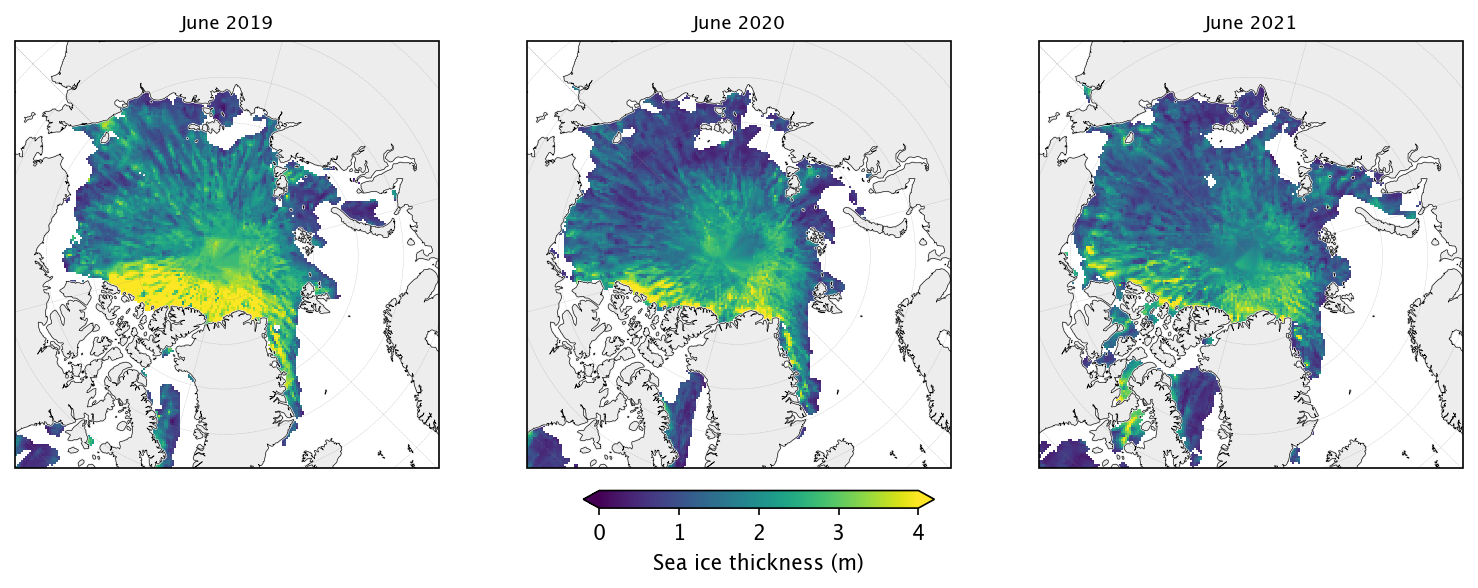

In [4]:

cmap = "viridis"
vmin, vmax = 0, 4
cbar_label = "Sea ice thickness (m)"


proj = ccrs.NorthPolarStereo(central_longitude=-45)
n = len(YEARS)
fig, axes = plt.subplots(
    1, n, subplot_kw={"projection": proj}, figsize=(n * 3.5, 3.8),
)
if n == 1:
    axes = [axes]

for idx, year in enumerate(YEARS):
    ax = axes[idx]
    ts = pd.Timestamp(year=year, month=ANALYSIS_MONTH, day=1)

    if ts not in is2_ds.time.values:
        ax.set_visible(False)
        continue

    data = is2_ds[ice_var].sel(time=ts)
    im = data.plot(
        ax=ax, x="longitude", y="latitude",
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        add_colorbar=False,
    )
    add_arctic_features(ax, extent=(-179, 179, 66, 90))
    ax.set_title(f"{month_name} {year}", fontsize=9)

cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    extend="both", fraction=0.04, pad=0.10)
cbar.set_label(cbar_label)
plt.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.18, wspace=0.05)
plt.show()

## 2. Read ERA5 cloud cover from Earthmover

Access the ERA5 surface reanalysis from the
[Earthmover Arraylake catalog](https://app.earthmover.io/marketplace/695bff20622fd82a1ec88780).
We use total cloud cover (`tcc`, 0–1) to estimate cloud attenuation of incoming solar
radiation. The `spatial` group is optimized for map-style queries.

In [5]:
ds_era5 = read_era5_earthmover(group="spatial")
print("ERA5 variables:", list(ds_era5.data_vars))
print("Time range:", str(ds_era5.time.values[0])[:10], "to", str(ds_era5.time.values[-1])[:10])

  2026-03-17T17:38:58.261424Z  WARN aws_config::provider_config: failed to parse profile, err: could not parse profile file: error parsing /Users/akpetty/.aws/config on line 12:
  Profile definition must end with ']' (ParseError(EnvConfigParseError { location: Location { line_number: 12, path: "/Users/akpetty/.aws/config" }, message: "Profile definition must end with ']'" }))
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/provider_config.rs:295

ERA5 variables: ['blh', 'cape', 'd2', 'sd', 'mslp', 'skt', 'lsp', 'cp', 'ssr', 'sst', 'swvl1', 't2', 'tcw', 'sp', 'stl1', 'tcc', 'ssrd', 'tcwv', 'u100', 'u10', 'v10', 'v100']
Time range: 1975-01-01 to 2024-12-31


## 3. Variable selection & multi-year light transmission loop

Using `ANALYSIS_MONTH` and `YEARS` set above, this section selects the IS2 ice/snow
variables, then loops over each year to fetch ERA5 cloud cover, regrid it, and run
the Beer-Lambert model.

In [6]:


sample = is2_ds.isel(time=0)
if ice_var not in sample.data_vars:
    ice_var = next((v for v in sample.data_vars if "ice_thickness" in v and "_unc" not in v), ice_var)
if snow_var not in sample.data_vars:
    snow_var = next((v for v in sample.data_vars if "snow_depth" in v and "_unc" not in v), snow_var)

print(f"Comparing {month_name} across {YEARS}")
print(f"Using ice thickness: '{ice_var}', snow depth: '{snow_var}'")

Comparing June across [2019, 2020, 2021]
Using ice thickness: 'ice_thickness_sm_m2_int', snow depth: 'snow_depth_sm_m2_int'


In [7]:
# ---- Albedo & surface transmittance per surface type ----
ALPHA_SNOW_ICE = 0.85   # snow-covered ice
ALPHA_BARE_ICE = 0.60   # bare white ice
ALPHA_POND     = 0.25   # melt ponds
ALPHA_OCEAN    = 0.06   # open water

I0_SNOW  = 0.30         # surface scattering layer transmittance (snow-covered)
I0_BARE  = 0.43         # bare ice
I0_POND  = 0.60         # melt pond

# ---- Extinction coefficients ----
KAPPA_SNOW = 15.0       # m^-1
KAPPA_ICE  = 1.5        # m^-1

# ---- Other parameters ----
F_PAR       = 0.43      # broadband SW → PAR
SNOW_THRESH = 0.03      # m — below this, surface counts as bare / ponded
F_POND      = 0.25      # assumed mean melt-pond fraction of ice area

DOY = DOY_MID[ANALYSIS_MONTH]
Q_toa = daily_mean_toa_insolation(is2_ds.latitude.values, DOY)

# ---- Loop over years: ERA5 fetch → regrid → Beer-Lambert ----
results = {}
for year in YEARS:
    ts = pd.Timestamp(year=year, month=ANALYSIS_MONTH, day=1)
    if ts not in is2_ds.time.values:
        print(f"  {ts:%Y-%m} — not in IS2 dataset, skipping")
        continue

    print(f"  {ts:%Y-%m} ...", end=" ")
    is2_snap = is2_ds.sel(time=ts)

    era5_date = f"{year}-{ANALYSIS_MONTH:02d}-15"
    tcc_era5 = (
        ds_era5.tcc
        .sel(time=slice(era5_date, era5_date), latitude=slice(90, 50))
        .mean(dim="time")
        .compute()
    )
    tcc = regrid_era5_to_is2(tcc_era5, is2_ds.latitude.values, is2_ds.longitude.values)

    h_ice  = is2_snap[ice_var].values
    h_snow = is2_snap[snow_var].values
    sic    = is2_snap.sea_ice_conc.values

    h_i = np.nan_to_num(h_ice, nan=0.0)
    h_s = np.nan_to_num(h_snow, nan=0.0)

    # Surface shortwave after cloud attenuation
    Q_surf = Q_toa * (1.0 - 0.75 * np.power(np.clip(tcc, 0, 1), 3.4))

    # --- Sub-area fractions within the ice-covered part ---
    is_snow = h_snow > SNOW_THRESH
    f_snow = np.where(is_snow, 1.0 - F_POND, 0.0)
    f_pond = np.where(is_snow, F_POND, F_POND)
    f_bare = 1.0 - f_snow - f_pond

    # --- Transmittance for each surface type (albedo × Beer-Lambert) ---
    T_snow = ((1 - ALPHA_SNOW_ICE) * I0_SNOW
              * np.exp(-KAPPA_SNOW * h_s - KAPPA_ICE * h_i))
    T_bare = (1 - ALPHA_BARE_ICE) * I0_BARE * np.exp(-KAPPA_ICE * h_i)
    T_pond = (1 - ALPHA_POND) * I0_POND * np.exp(-KAPPA_ICE * h_i)

    # Effective ice-area transmittance (weighted by sub-area fractions)
    T_ice = f_snow * T_snow + f_bare * T_bare + f_pond * T_pond

    T_ow = 1.0 - ALPHA_OCEAN

    # Grid-cell PAR
    par_ice = Q_surf * T_ice * F_PAR
    par_ow  = Q_surf * T_ow * F_PAR
    par_gc  = np.where(np.isfinite(sic),
                       sic * par_ice + (1.0 - sic) * par_ow, np.nan)

    results[year] = dict(
        h_ice=h_ice, h_snow=h_snow, sic=sic,
        Q_toa=Q_toa, tcc=tcc, Q_surf=Q_surf,
        T_snow=T_snow, T_bare=T_bare, T_pond=T_pond, T=T_ice,
        f_snow=f_snow, f_bare=f_bare, f_pond=f_pond,
        PAR_under_ice=par_ice, PAR_ocean=par_gc,
    )
    print(f"under-ice PAR median {np.nanmedian(par_ice):.1f} W/m²")

print(f"\nComputed light transmission for {len(results)} years.")

  2019-06 ... under-ice PAR median 29.6 W/m²
  2020-06 ... under-ice PAR median 32.4 W/m²
  2021-06 ... under-ice PAR median 32.3 W/m²

Computed light transmission for 3 years.


In [8]:
# (ERA5 regridding is now done inside the multi-year loop above)

## 4. Beer-Lambert light transmission model with albedo & melt ponds

We estimate under-ice PAR (photosynthetically active radiation, 400–700 nm) through a
multi-surface-type model.  Each ice-covered grid cell is partitioned into three sub-areas
weighted by their respective fractions:

$$f_{\text{pond}},\quad f_{\text{bare}} = \max(0,\; 1 - f_{\text{pond}} - f_{\text{snow}}),\quad f_{\text{snow}} = 1 - f_{\text{pond}} - f_{\text{bare}}$$

where snow cover is diagnosed from the snow depth field ($h_s > $ threshold → snow-covered).

**Step 1 — Incoming surface shortwave**
$$Q_{\text{surface}} = Q_{\text{TOA}} \;\bigl(1 - 0.75\,C_{\text{cloud}}^{\,3.4}\bigr)$$

**Step 2 — Transmittance for each surface type** (Beer-Lambert)

| Surface type | Albedo $\alpha$ | Transmittance $T$ |
|---|---|---|
| Snow-covered ice | $\alpha_{\text{snow}}$ | $(1-\alpha_{\text{snow}})\; i_{0,s}\; e^{-\kappa_s h_s - \kappa_i h_i}$ |
| Bare ice | $\alpha_{\text{ice}}$ | $(1-\alpha_{\text{ice}})\; i_{0,b}\; e^{-\kappa_i h_i}$ |
| Melt pond | $\alpha_{\text{pond}}$ | $(1-\alpha_{\text{pond}})\; i_{0,p}\; e^{-\kappa_i h_i}$ |
| Open water | $\alpha_{\text{ow}}$ | $(1-\alpha_{\text{ow}})$ |

**Step 3 — Grid-cell under-ice PAR**
$$\text{PAR}_{\text{gc}} = Q_{\text{surface}} \times f_{\text{PAR}} \times \Bigl[
  \text{SIC}\bigl(f_s\,T_s + f_b\,T_b + f_p\,T_p\bigr) + (1-\text{SIC})(1-\alpha_{\text{ow}})
\Bigr]$$

| Parameter | Symbol | Value | Reference |
|---|---|---|---|
| Snow-covered ice albedo | $\alpha_{\text{snow}}$ | 0.85 | Perovich et al. (2002) |
| Bare ice albedo | $\alpha_{\text{ice}}$ | 0.60 | Perovich et al. (2002) |
| Melt pond albedo | $\alpha_{\text{pond}}$ | 0.25 | Flocco et al. (2012) |
| Open-water albedo | $\alpha_{\text{ow}}$ | 0.06 | — |
| Surface transmittance (snow-covered) | $i_{0,s}$ | 0.30 | Light et al. (2008) |
| Surface transmittance (bare ice) | $i_{0,b}$ | 0.43 | Light et al. (2008) |
| Surface transmittance (melt pond) | $i_{0,p}$ | 0.60 | Light et al. (2015) |
| Snow extinction | $\kappa_s$ | 15 m$^{-1}$ | Perovich (1996) |
| Ice extinction | $\kappa_i$ | 1.5 m$^{-1}$ | Grenfell & Maykut (1977) |
| PAR fraction of SW | $f_{\text{PAR}}$ | 0.43 | Frouin & Pinker (1995) |
| Mean melt pond fraction | $f_{\text{pond}}$ | 0.25 | Rösel & Kaleschke (2012) |

In [9]:
# (Model computation is now done inside the multi-year loop above)

## 5. Compare inputs and outputs across years

Each row is one year; columns show ice thickness, snow depth, cloud cover,
surface shortwave, transmittance, and under-ice PAR.

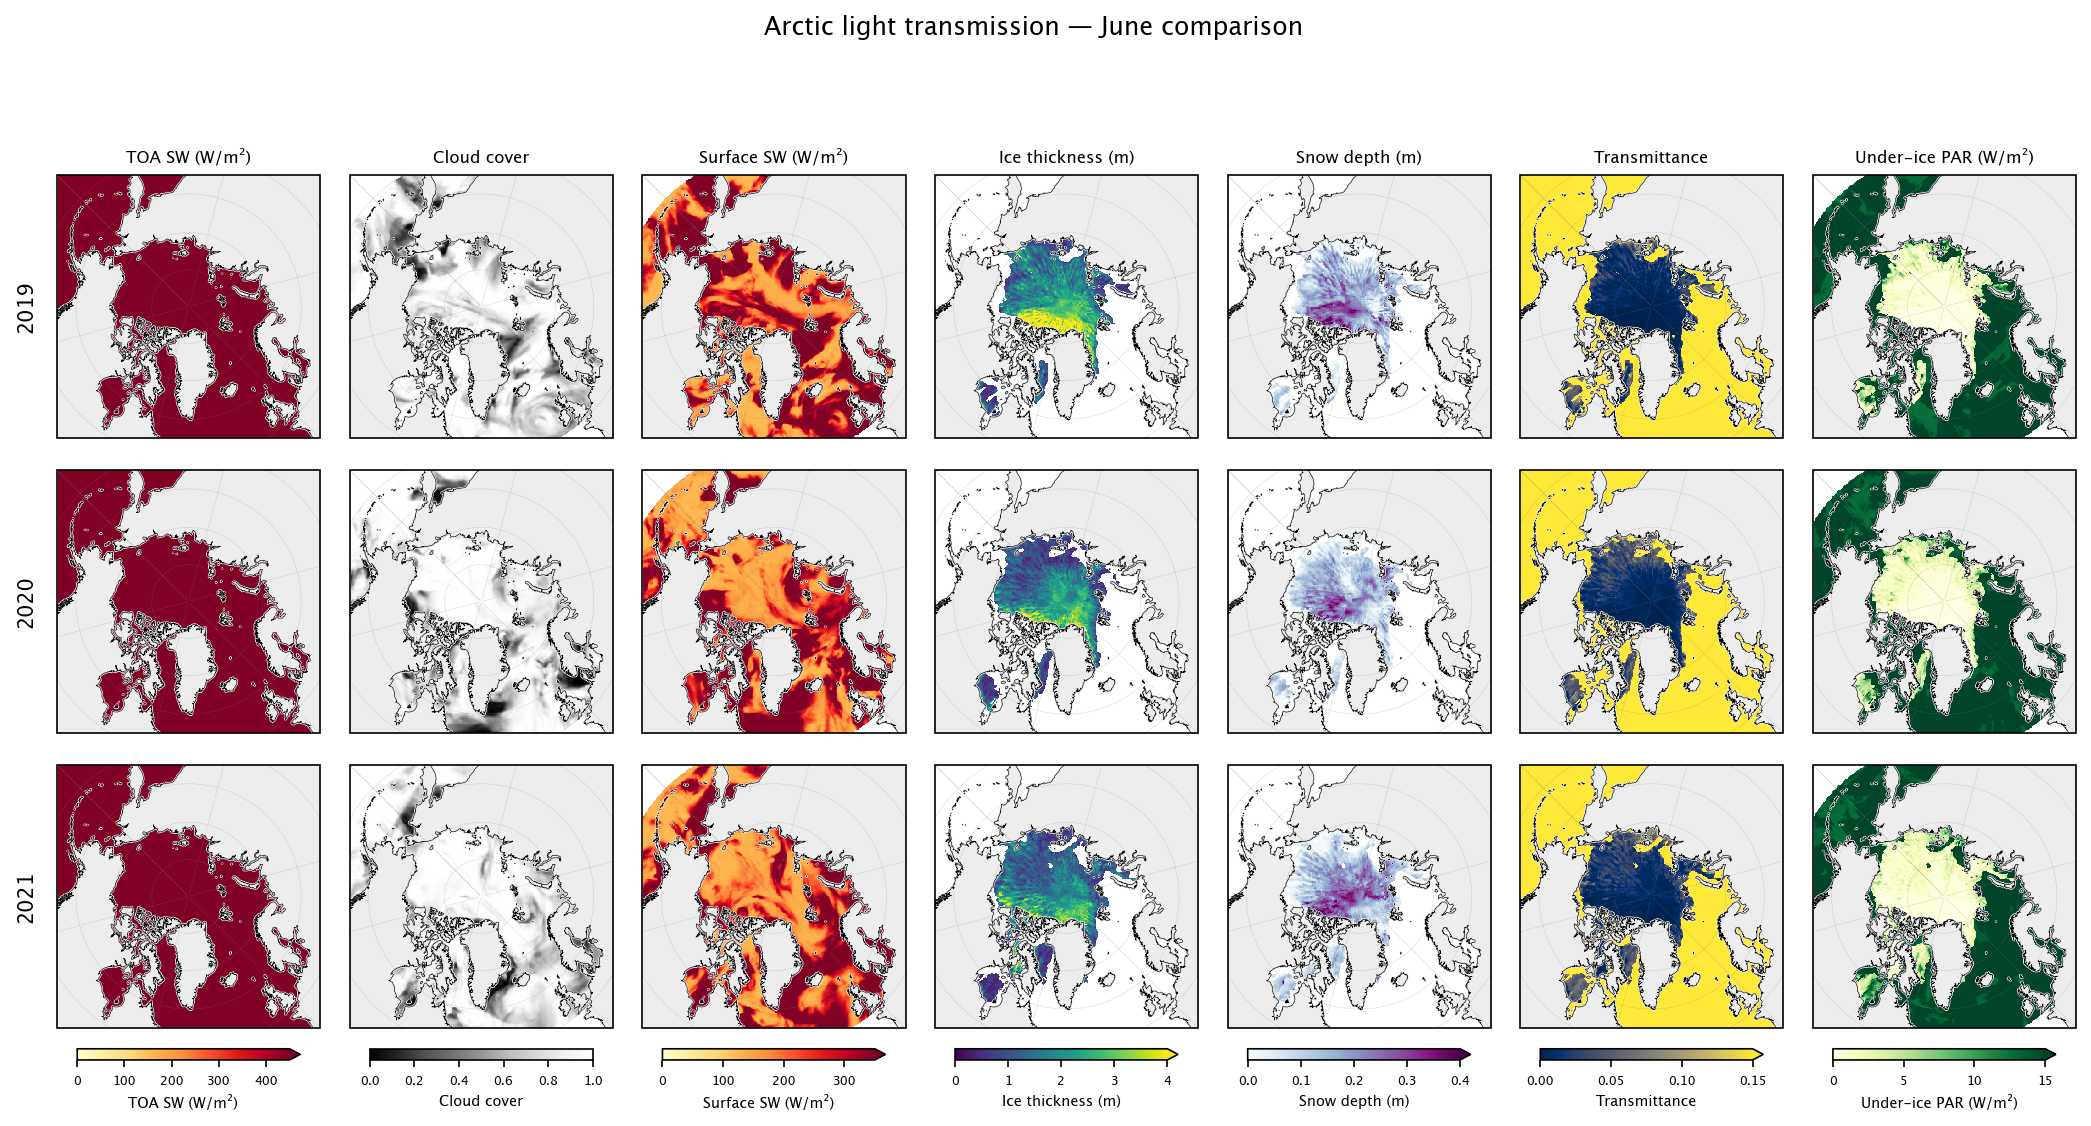

In [14]:
proj = ccrs.NorthPolarStereo(central_longitude=-45)
transform = ccrs.PlateCarree()
lon2d = is2_ds.longitude.values
lat2d = is2_ds.latitude.values

col_specs = [
    ("Q_toa",          "YlOrRd",  0, 450,  "TOA SW (W/m²)",         1),
    ("tcc",            "Greys_r", 0, 1,    "Cloud cover",           1),
    ("Q_surf",         "YlOrRd",  0, 350,  "Surface SW (W/m²)",     1),
    ("h_ice",          "viridis", 0, 4,    "Ice thickness (m)",     1),
    ("h_snow",         "BuPu",    0, 40,   "Snow depth (cm)",     100),
    ("T",              "cividis", 0, 0.15, "Transmittance",         1),
    ("PAR_under_ice",  "YlGn",    0, 15,   "Under-ice PAR (W/m²)",  1),
]

years_avail = sorted(results.keys())
nrows, ncols = len(years_avail), len(col_specs)

fig = plt.figure(figsize=(ncols * 2.5, nrows * 2.8 + 0.5))
gs = gridspec.GridSpec(nrows, ncols, wspace=0.05, hspace=0.12)

for ri, year in enumerate(years_avail):
    r = results[year]
    for ci, (key, cmap, vmin, vmax, label, scale) in enumerate(col_specs):
        ax = fig.add_subplot(gs[ri, ci], projection=proj)
        im = ax.pcolormesh(
            lon2d, lat2d, r[key] * scale, transform=transform,
            cmap=cmap, vmin=vmin, vmax=vmax,
        )
        add_arctic_features(ax)
        if ri == 0:
            ax.set_title(label, fontsize=8)
        if ci == 0:
            ax.text(-0.08, 0.5, str(year), transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", ha="right",
                    rotation=90)

for ci, (key, cmap, vmin, vmax, label, scale) in enumerate(col_specs):
    extend = "neither" if key in ("tcc", "Q_toa") else "max"
    ax_last = fig.axes[ci + (nrows - 1) * ncols]
    cb = plt.colorbar(
        ax_last.collections[0], ax=fig.axes[ci::ncols],
        orientation="horizontal", shrink=0.8, pad=0.02, extend=extend,
    )
    cb.set_label(label, fontsize=7)
    cb.ax.tick_params(labelsize=6)

fig.suptitle(f"Arctic light transmission — {month_name} comparison", fontsize=12, y=1.0)
plt.show()

## 6. Identify high-transmission regions across years (pack ice)

We restrict this analysis to **pack ice** (SIC ≥ `SIC_MIN`, default 0.5) where
IS2 provides reliable thickness retrievals. Grid-cells where under-ice PAR exceeds
the threshold indicate areas where thin ice and/or low snow cover may allow
ecologically significant light levels beneath the ice.
Shown for each available year side-by-side. Adjust `SIC_MIN` in Section 1 to
change the pack-ice concentration threshold.

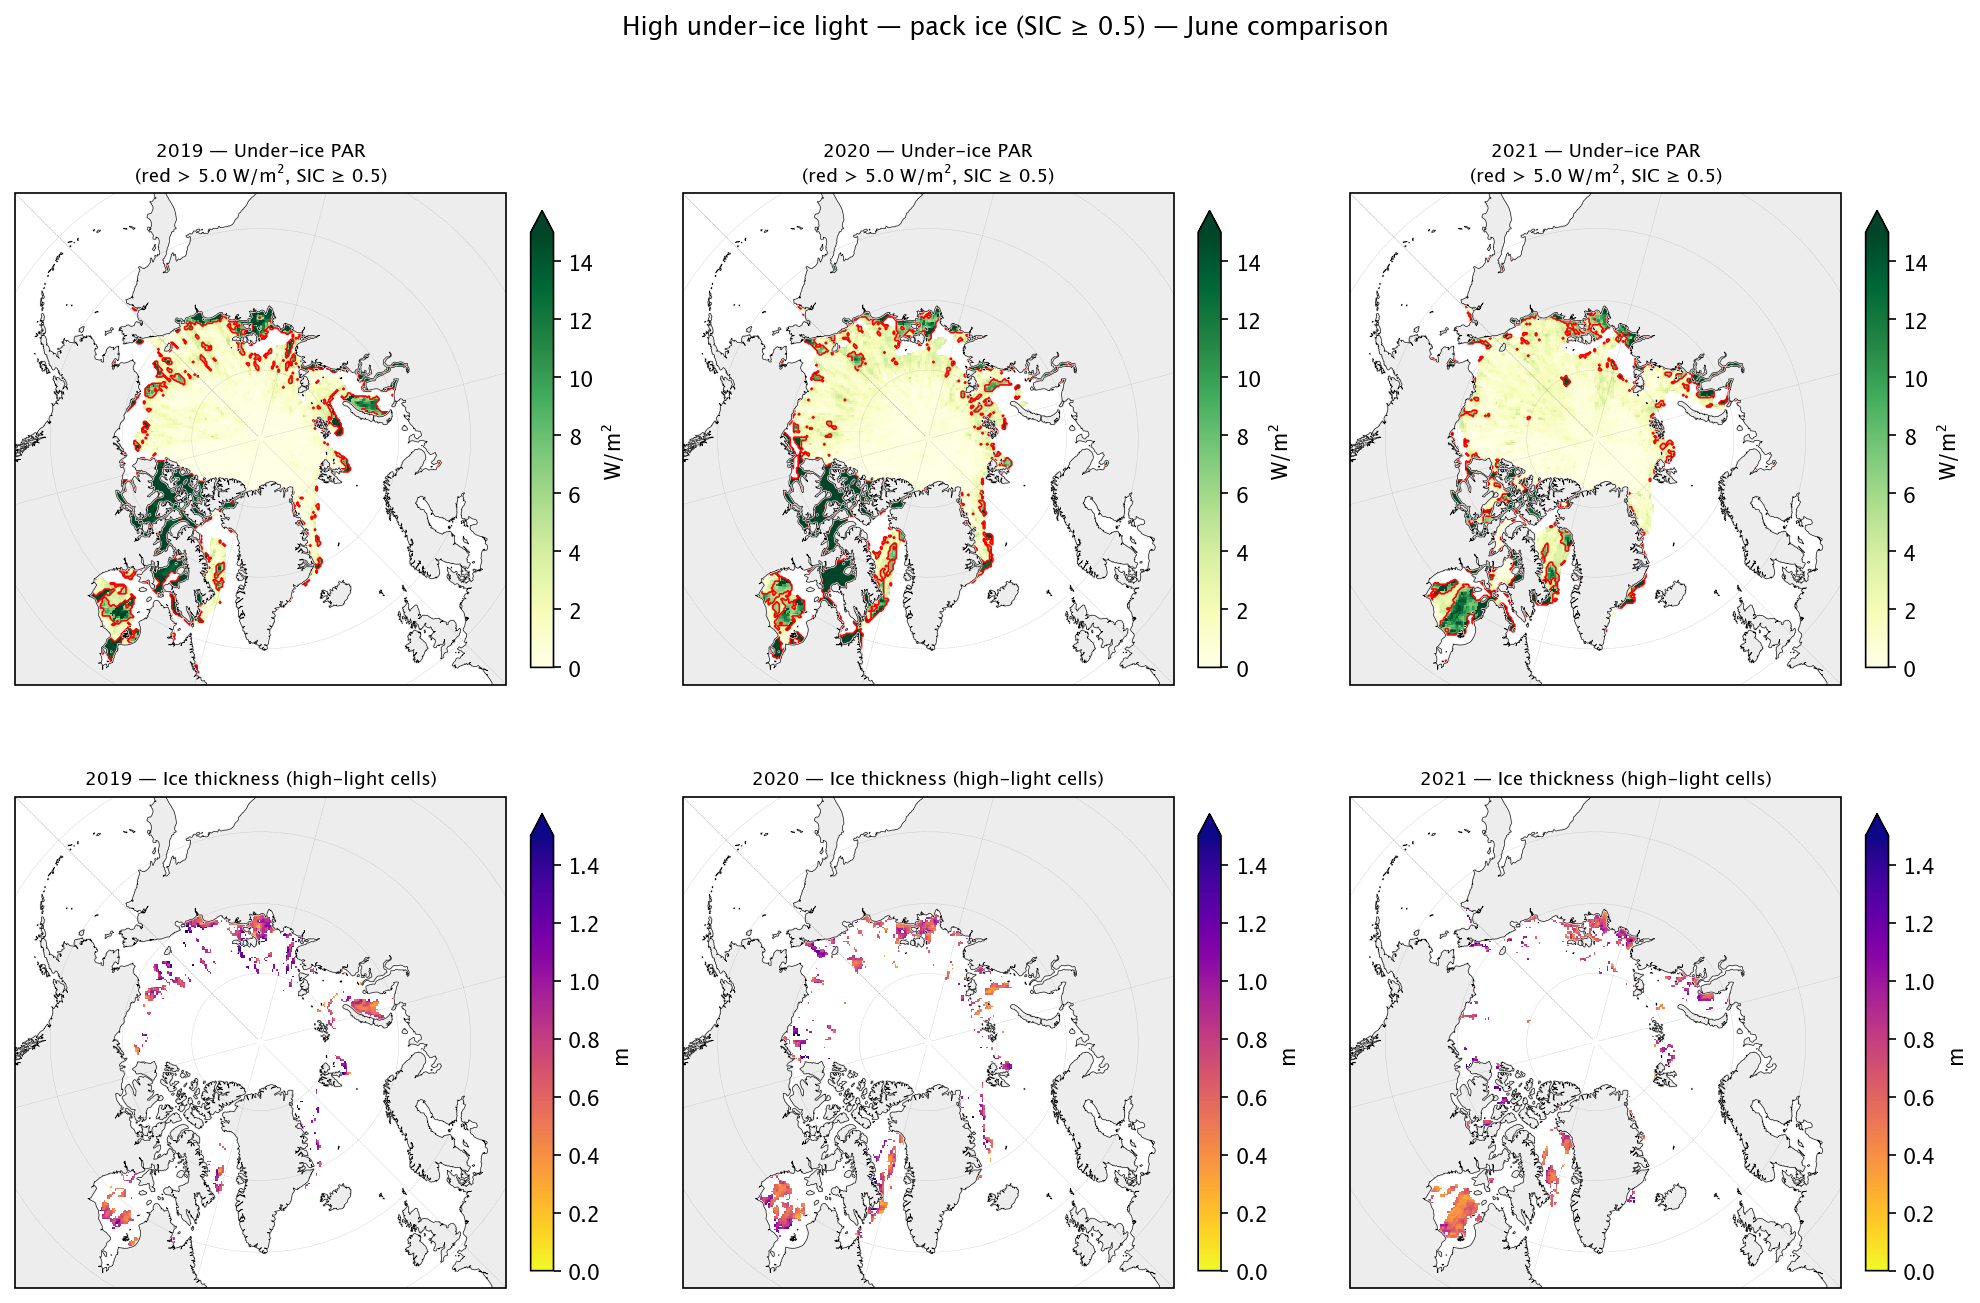

In [11]:
PAR_THRESHOLD = 5.0  # W/m²
years_avail = sorted(results.keys())
n = len(years_avail)

fig, axes = plt.subplots(
    2, n, figsize=(n * 4.5, 9),
    subplot_kw={"projection": proj},
)
if n == 1:
    axes = axes.reshape(2, 1)

for ci, year in enumerate(years_avail):
    r = results[year]
    sic_y = r["sic"]
    pack_mask = np.isfinite(sic_y) & (sic_y >= SIC_MIN)
    high_light = (r["PAR_under_ice"] > PAR_THRESHOLD) & pack_mask

    par_masked = np.where(pack_mask, r["PAR_under_ice"], np.nan)

    ax = axes[0, ci]
    im = ax.pcolormesh(
        lon2d, lat2d, par_masked, transform=transform,
        cmap="YlGn", vmin=0, vmax=15,
    )
    hl_float = high_light.astype(float)
    mask_pos = lon2d >= 0
    mask_neg = lon2d < 0
    for mask in (mask_pos, mask_neg):
        lon_m = np.where(mask, lon2d, np.nan)
        dat_m = np.where(mask, hl_float, np.nan)
        ax.contour(
            lon_m, lat2d, dat_m,
            levels=[0.5], colors="red", linewidths=0.8, transform=transform,
        )
    add_arctic_features(ax)
    ax.set_title(f"{year} — Under-ice PAR\n(red > {PAR_THRESHOLD} W/m², SIC ≥ {SIC_MIN})", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04, extend="max", label="W/m²")

    ax = axes[1, ci]
    h_ice_hl = np.where(high_light, r["h_ice"], np.nan)
    im = ax.pcolormesh(
        lon2d, lat2d, h_ice_hl, transform=transform,
        cmap="plasma_r", vmin=0, vmax=1.5,
    )
    add_arctic_features(ax)
    ax.set_title(f"{year} — Ice thickness (high-light grid-cells)", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04, extend="max", label="m")

fig.suptitle(
    f"High under-ice light — pack ice (SIC ≥ {SIC_MIN}) — {month_name} comparison",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## 7. Summary statistics — year-by-year comparison (pack ice, SIC ≥ `SIC_MIN`)

In [16]:
rows = []
for year in sorted(results.keys()):
    r = results[year]
    pack_mask = np.isfinite(r["sic"]) & (r["sic"] >= SIC_MIN)
    n_pack = np.sum(pack_mask)
    high_light = (r["PAR_under_ice"] > PAR_THRESHOLD) & pack_mask
    rows.append({
        "Year": year,
        "Grid-cells": int(n_pack),
        "h_ice (m)": np.nanmean(r["h_ice"][pack_mask]),
        "h_snow (cm)": np.nanmean(r["h_snow"][pack_mask]) * 100,
        "TOA SW": np.nanmean(r["Q_toa"][pack_mask]),
        "Cloud": np.nanmean(r["tcc"][pack_mask]),
        "Sfc SW": np.nanmean(r["Q_surf"][pack_mask]),
        "Trans.": np.nanmean(r["T"][pack_mask]),
        "PAR (W/m²)": np.nanmean(r["PAR_under_ice"][pack_mask]),
        f"PAR>{PAR_THRESHOLD} %": 100 * np.sum(high_light) / n_pack,
        "h_ice HL (m)": np.nanmean(r["h_ice"][high_light]),
        "h_snow HL (cm)": np.nanmean(r["h_snow"][high_light]) * 100,
    })

summary_df = pd.DataFrame(rows).set_index("Year")
summary_df.style.format(precision=3)

,Grid-cells,h_ice (m),h_snow (m),TOA SW,Cloud,Sfc SW,Trans.,PAR (W/m²),PAR>5.0 %,h_ice HL (m),h_snow HL (m)
Year,,,,,,,,,,,
2019,15046,1.991,0.137,521.968,0.820,281.260,0.055,6.578,26.605,0.788,0.052
2020,15073,1.561,0.120,521.425,0.854,247.557,0.059,7.721,26.823,0.707,0.047
2021,15382,1.527,0.133,521.290,0.895,222.152,0.049,5.439,22.143,0.670,0.051


### Interpretation

The table above reveals how the different drivers interact to control under-ice
PAR across the three June snapshots (2019–2021):

**Ice thickness is the dominant control.** Mean pack-ice thickness dropped from
~2.0 m (2019) to ~1.5 m (2020–2021), a ~25 % thinning. Because light decays
exponentially through ice, even modest thinning produces a large increase in
transmittance — mean transmittance rose from 0.055 (2019) to 0.059 (2020)
despite higher cloud cover in 2020. The mean thickness within high-transmission
grid-cells (PAR > 5 W/m²) is substantially lower than the pack-ice average,
confirming that thin ice is the primary gateway for under-ice light.

**Snow depth has a secondary but important role.** Snow is far more opaque than
ice (κ_snow = 15 m⁻¹ vs κ_ice = 1.5 m⁻¹), so a few centimetres of difference
matter. 2020 had the lowest mean snow depth (0.12 m vs 0.13–0.14 m in the other
years), which contributed to its having the highest transmittance.

**Cloud cover modulates the incoming energy budget.** TOA insolation is
essentially identical across years (~522 W/m²) since it depends only on latitude
and day of year. Cloud cover, however, varied substantially: mean TCC increased
from 0.82 (2019) to 0.90 (2021), reducing surface shortwave from ~281 to
~222 W/m². This ~21 % drop in surface SW between 2019 and 2021 directly scales
the under-ice PAR, partially offsetting the effect of thinner ice in 2021.

**Net effect on under-ice PAR.** The interplay between these factors produces a
non-obvious result: 2020 had the highest mean under-ice PAR (7.7 W/m²) because
it combined thin ice and low snow with only moderately high cloud cover. By
contrast, 2021 had comparable ice thickness but much higher cloud cover, yielding
the lowest PAR (5.4 W/m²). The fraction of pack-ice grid-cells exceeding the
5 W/m² threshold ranged from ~22 % (2021) to ~27 % (2019–2020).

**In summary**, ice thickness and snow depth set the *transmittance* of the ice
column, while cloud cover controls the *amount of energy available* to be
transmitted. Both matter — a cloudy summer over thin ice can produce less
under-ice light than a clearer summer over thicker ice.

## Next steps

This proof-of-concept compares under-ice light across three summers using explicit
albedo and melt-pond assumptions. Potential improvements:

- **Spectral resolution**: use wavelength-dependent extinction coefficients instead of broadband values
- **Spatially varying melt-pond fraction**: replace the fixed `F_POND` with satellite-derived pond fraction maps (e.g. MODIS)
- **Full seasonal cycle**: extend to May–August monthly evolution to capture the spring bloom window
- **Validation**: compare modeled under-ice PAR against buoy-based observations (e.g. ice-tethered profilers)
- **Monthly ERA5 means**: replace the single-day cloud cover with monthly averages for more robust estimates
- **Ice type**: differentiate first-year vs. multi-year ice extinction properties and albedo
- **Trend analysis**: quantify year-to-year changes in high-transmission area and mean under-ice PAR